In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.comment_108 import Comment108Model
from networks.cnn_network import build_dataloader


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, fractions,boundaries,interpretation,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,igm,iga,label as raw_label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

patterns = ['m-komponent < 1 g/l', 'specifik immunisering', 'lätt avvikande immunglobulinfördelning', 'lätt avavikande immunglobulinfördelning']

def has_valid_text(text):
    text_lower = str(text).lower()
    return any(p in text_lower for p in patterns)

df = df[df['raw_label'].isin([0, 2])].copy()

correct_label = df['raw_label'] == 2
valid_text = df['interpretation'].apply(has_valid_text)

df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

cnn = Comment108Model()
train_dl = build_dataloader(train_rows)
val_dl = build_dataloader(val_rows)
test_dl = build_dataloader(test_rows)
#cnn.retrain(train_dl=train_dl,val_dl=val_dl,patience=10)

Antal utan kommentar 108 i träningsdatan: 17653
Antal med kommentar 108 i träningsdatan: 2983


In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, fractions,boundaries,interpretation,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,igm,iga,label as raw_label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

patterns = ['m-komponent < 1 g/l', 'specifik immunisering', 'lätt avvikande immunglobulinfördelning', 'lätt avavikande immunglobulinfördelning']

def has_valid_text(text):
    text_lower = str(text).lower()
    return any(p in text_lower for p in patterns)

df = df[df['raw_label'].isin([0, 2])].copy()

correct_label = df['raw_label'] == 2
valid_text = df['interpretation'].apply(has_valid_text)

df['label'] = ((correct_label) | (valid_text)).astype(int)


kfold_rows = df[df['set'].isin(['train','val']) ].copy()

drop_indices = kfold_rows[kfold_rows['label'] == 0].sample(frac=0.7).index

kfold_rows = kfold_rows.drop(drop_indices)

print(f"Antal utan kommentar 108 i datan: {len(kfold_rows[kfold_rows['label'] == 0])}")
print(f"Antal med kommentar 108 i datan: {len(kfold_rows[kfold_rows['label'] == 1])}")

cnn = Comment108Model()
cnn.retrain_with_k_fold(kfold_rows)

Antal utan kommentar 108 i datan: 18587
Antal med kommentar 108 i datan: 3119
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
Epoch   0 | train: 0.7479 | val: 0.6787 | acc: 81.67% | AUC: 0.645  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   1 | train: 0.6727 | val: 0.6498 | acc: 62.83% | AUC: 0.687  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   2 | train: 0.6579 | val: 0.6454 | acc: 68.31% | AUC: 0.694  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   3 | train: 0.6494 | val: 0.6462 | acc: 61.03% | AUC: 0.696  | LR: 0.001
Epoch   4 | train: 0.6456 | val: 0.6456 | acc: 72.82% | AUC: 0.699  | LR: 0.001
Epoch   5 | train: 0.6433 | val: 0.6179 | acc: 70.24% | AUC: 0.699  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   6 | train: 0.6365 | val: 0.6341 | acc: 76.74% | AUC: 0.700  | LR: 0.001
Epoch   7 | train: 0.6338 | val: 0.6304 | acc: 63

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.213996,0.306099,85.997236,0.944908
1,2,0.221223,0.347306,86.399262,0.934439
2,3,0.235676,0.300206,86.872409,0.947037
3,4,0.251698,0.309901,84.423963,0.939266
4,5,0.248577,0.301141,85.122064,0.944040
5,6,0.237475,0.351805,85.490557,0.940556
6,7,0.278976,0.320504,83.732719,0.936977
7,8,0.216313,0.299937,84.838710,0.943524
8,9,0.241758,0.300130,87.090825,0.941954
9,10,0.249793,0.307387,86.802030,0.938285


Totala mängd datapunkter: 3301
              precision    recall  f1-score   support

     Negativ       0.99      0.87      0.93      3193
     Positiv       0.17      0.80      0.28       108

    accuracy                           0.87      3301
   macro avg       0.58      0.83      0.61      3301
weighted avg       0.97      0.87      0.91      3301

[[2779  414]
 [  22   86]]
AUC: 0.9193664381575436
Accuracy:  86.79%
FN-rate:   20.37%  (farliga missade fall)
FP-rate:   12.97%  (onödiga larm)
Sensitivitet:   79.63%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   87.03%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9194


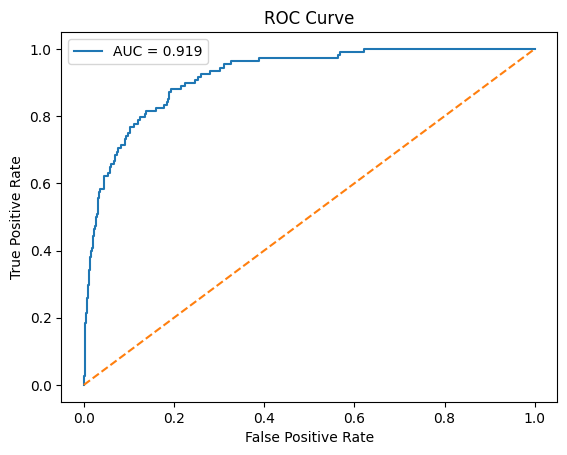

In [2]:
result = cnn.predict(test_rows)
result = cnn.evaluate(val_rows,threshold=0.5)